<a href="https://colab.research.google.com/github/hkaido0718/SupportRestriction/blob/main/IVModel_Exclusion_Monotonicity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The `IVModel` class: exclusion and D-monotonicity with a binary instrument
Let $Y\in\{0,1\}$ denote an outcome, $D\in\{0,1\}$ a treatment, and $Z\in\{0,1\}$ an instrument. For example, $Y$ is employment, $D$ is participation in a training program, and $Z$ is a randomly assigned offer to participate. Let $D(z)$ and $Y(d,z)$ denote the potential treatment and the potential outcome, and suppose the observed responses are generated by $D=D(Z)$ and $Y=Y(D(Z),Z)$, where $Z$ is randomly assigned, so that the full vector $\big((Y(d,z))_{d,z},(D(z))_z\big)$ is independent of $Z$.

The `IVModel` class in `iv_model.py` represents three models, selected by two flags:

\begin{align}
&\text{Exclusion:}\qquad Y(d,z)=Y(d,z') \quad\text{for all } d \text{ and all } z,z';\\
&\text{D-monotonicity:}\qquad D(z)\leqslant_{a.s.} D(z') \quad\text{whenever } z<z'.
\end{align}

| Specification | `exclusion` | `d_monotonicity` |
|---|---|---|
| Exclusion only (the default) | `True` | `False` |
| D-monotonicity only | `False` | `True` |
| Both | `True` | `True` |

No outcome monotonicity is imposed. Each model is represented by a graph $G$ whose nodes are the observable events $(y,d,z)$. `IVModel.build_graph()` constructs $G$ by Method 1 of Kaido and Ponomarev (2025), and the graph is then analyzed with the authors' `GraphAnalyzer`, exactly as in the other notebooks in this repository.

In [1]:
# Inside a local checkout, the modules are importable from the working directory.
# Anywhere else (for example Google Colab), fetch the repository and add it to the path.
import os
import sys

if not os.path.isfile("iv_model.py"):
    if not os.path.isdir("SupportRestriction"):
        !git clone https://github.com/hkaido0718/SupportRestriction.git
    sys.path.insert(0, os.path.abspath("SupportRestriction"))

### Graph construction (Method 1 inside `IVModel`)
The researcher specifies the supports and the two flags. `build_graph()` adds every node $(y,d,z)$, visits each pair of nodes with different values of $z$ once, and joins the pair unless an enabled assumption rules out observing both events: exclusion rejects equal treatments with unequal outcomes, and D-monotonicity rejects a treatment that falls as the instrument rises. Nodes with the same $z$ are never joined, because $D=D(Z)$ takes one value at a given $Z$.

In [2]:
import networkx as nx
from iv_model import IVModel
from graph_analysis_utils import GraphAnalyzer

specs = {
    "Exclusion only": dict(exclusion=True, d_monotonicity=False),
    "D-monotonicity only": dict(exclusion=False, d_monotonicity=True),
    "Both": dict(exclusion=True, d_monotonicity=True),
}
models = {
    name: IVModel(y_support=(0, 1), d_support=(0, 1), z_support=(0, 1), **flags)
    for name, flags in specs.items()
}
graphs = {name: model.build_graph() for name, model in models.items()}

for name, G in graphs.items():
    print(f"{name:20s} nodes = {G.number_of_nodes()}, edges = {G.number_of_edges()}")

Exclusion only       nodes = 8, edges = 12
D-monotonicity only  nodes = 8, edges = 12
Both                 nodes = 8, edges = 8


In [3]:
print(models["Both"].summary())

IVModel: discrete instrumental-variable model (Kaido and Ponomarev, 2025)
  Outcome support Y:    (0, 1)
  Treatment support D:  (0, 1)
  Instrument support Z: (0, 1)
  Nodes (y, d, z):      8
  Potential responses: D(z) and Y(d, z); observed D = D(Z), Y = Y(D(Z), Z).
  Assumptions:
    - Exclusion: imposed. Y(d, z) = Y(d, z') for every treatment value d and every pair of instrument values z, z'.
    - D-monotonicity: imposed. D(z) <= D(z') whenever z < z' (treatment is nondecreasing in the instrument).
    - No outcome monotonicity is imposed.
  Maintained (not a pairwise rule): the full potential-response vector
    ((Y(d, z))_{d, z}, (D(z))_z) is independent of Z.
  Graph: build_graph() applies Method 1 (pairwise compatibility) and returns
    a networkx.Graph for GraphAnalyzer.


### Plot graphs
Each node is a triple $(y,d,z)$, coloured by the value of $z$. Exclusion removes the four edges joining equal treatments with unequal outcomes; D-monotonicity removes the four edges joining $d=1$ at $z=0$ with $d=0$ at $z=1$. The two sets are disjoint, so the third graph has eight edges.

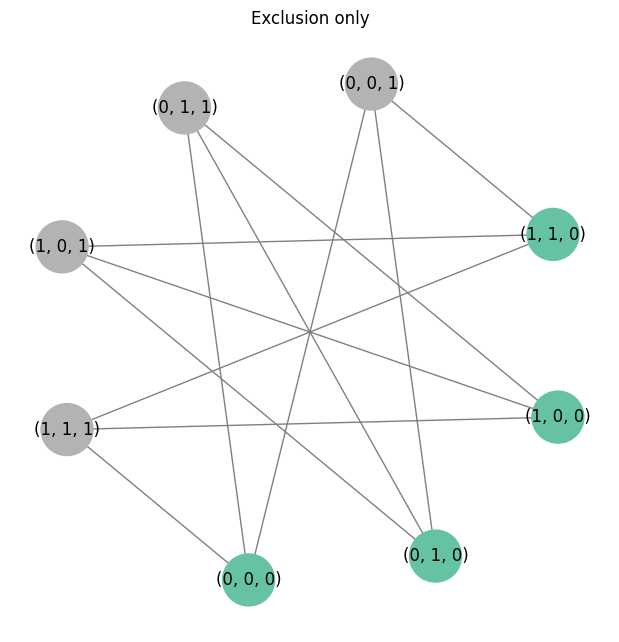

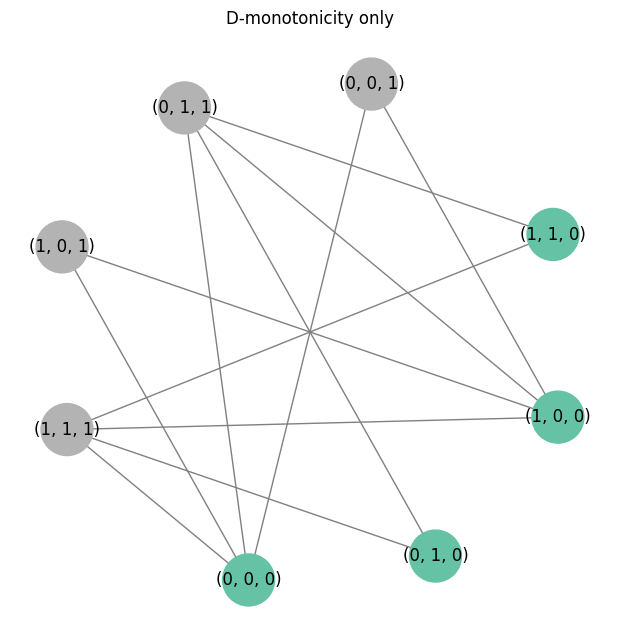

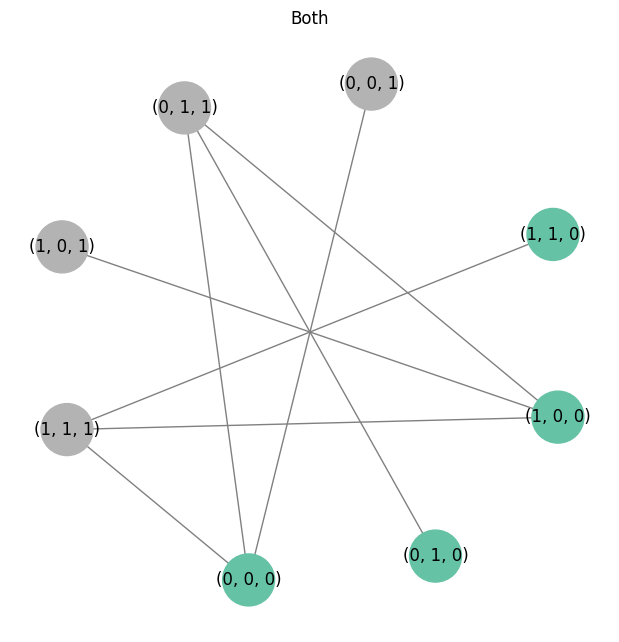

In [4]:
for name, model in models.items():
    analyzer = GraphAnalyzer(graphs[name], group_fn=model.group_fn)
    analyzer.plot_grouped_on_circle(title=name, node_size=1400)

### Get MIS and testable implications
Each maximal independent set $I$ of $G$ that is not contained in a single $z$-group gives the inequality $\sum_{(y,d,z)\in I} P(Y=y,D=d\mid Z=z)\leqslant 1$ (Theorem 1 of Kaido and Ponomarev, 2025): under random assignment $P(Y=y,D=d\mid Z=z)=P(Y(D(z),z)=y,D(z)=d)$, and the events for the nodes of $I$ are mutually exclusive because no admissible potential-response vector generates two of them.

In [5]:
for name, model in models.items():
    print(f"=== {name} ===")
    GraphAnalyzer(graphs[name], group_fn=model.group_fn).print_mis_excluding_single_group()

=== Exclusion only ===
Total MISs (excluding single-group ones): 4

1: [(0, 0, 1), (1, 0, 0)]
2: [(0, 0, 0), (1, 0, 1)]
3: [(0, 1, 1), (1, 1, 0)]
4: [(0, 1, 0), (1, 1, 1)]
=== D-monotonicity only ===
Total MISs (excluding single-group ones): 1

1: [(0, 0, 1), (0, 1, 0), (1, 0, 1), (1, 1, 0)]
=== Both ===
Total MISs (excluding single-group ones): 5

1: [(0, 0, 1), (0, 1, 0), (1, 0, 0), (1, 1, 0)]
2: [(0, 0, 0), (0, 1, 0), (1, 0, 1), (1, 1, 0)]
3: [(0, 0, 1), (0, 1, 0), (1, 0, 1), (1, 1, 0)]
4: [(0, 0, 1), (0, 1, 1), (1, 0, 1), (1, 1, 0)]
5: [(0, 0, 1), (0, 1, 0), (1, 0, 1), (1, 1, 1)]


**Exclusion only.** The four MISs are the pairs $\{(y,d,0),(1-y,d,1)\}$, giving

\begin{align}
P(Y=y,D=d\mid Z=0)+P(Y=1-y,D=d\mid Z=1)\leqslant 1,\qquad y,d\in\{0,1\},
\end{align}

the instrumental inequalities of Pearl (1995) for a binary instrument; see eq. (4.6) of Kaido and Ponomarev (2025) with $A=\{y\}$.

**D-monotonicity only.** The single MIS collects $D=1$ at $Z=0$ and $D=0$ at $Z=1$, both outcome values included: $P(D=1\mid Z=0)+P(D=0\mid Z=1)\leqslant 1$, that is, $P(D=1\mid Z=0)\leqslant P(D=1\mid Z=1)$. Outcomes place no restriction because $Y(d,z)$ is unrestricted.

**Both.** Five MISs. Four of them are the inequalities of Balke and Pearl (1997) and Kitagawa (2015),

\begin{align}
P(Y=y,D=1\mid Z=0)\leqslant P(Y=y,D=1\mid Z=1),\qquad P(Y=y,D=0\mid Z=1)\leqslant P(Y=y,D=0\mid Z=0),\qquad y\in\{0,1\},
\end{align}

in the form of eq. (4.7)-(4.8) of the paper. For example, the MIS printed fourth, $\{(0,0,1),(0,1,1),(1,0,1),(1,1,0)\}$, reads $P(D=0\mid Z=1)+P(Y=0,D=1\mid Z=1)+P(Y=1,D=1\mid Z=0)\leqslant 1$, which is the first inequality with $y=1$ because $P(D=0\mid Z=1)+P(Y=0,D=1\mid Z=1)=1-P(Y=1,D=1\mid Z=1)$. Each of these four tightens one exclusion-only inequality by adding $P(D=0\mid Z=1)$ or $P(D=1\mid Z=0)$ to its left-hand side, as Proposition 2 of the paper describes. The remaining MIS, printed third, collects $D=1$ at $Z=0$ and $D=0$ at $Z=1$ and is the monotonicity inequality $P(D=1\mid Z=0)\leqslant P(D=1\mid Z=1)$; it follows from summing the first displayed inequality over $y$ (the MISs printed fourth and fifth), so the list is complete but not irredundant (Remark 2 of the paper).

### Check regularity condition
With a binary instrument every support restriction is regular (Kaido and Ponomarev, 2025, Section 3.3): the graph is bipartite, hence perfect, and every maximal clique is a single edge, one node per value of $z$, which is a support point by the pairwise argument. We verify both conditions numerically with `is_perfect()` and the enumeration of the maximal cliques, checking that each contains exactly one node per instrument value. The ✅ marks only confirm that no pair inside a clique violates the enabled rules, which holds by construction of $G$. By Theorem 3 of the paper the MIS inequalities above are therefore sharp for each of the three models.

In [6]:
for name, model in models.items():
    analyzer = GraphAnalyzer(graphs[name], group_fn=model.group_fn)
    rows = analyzer.enumerate_cliques_and_check(model.violate_pairwise_fn)
    one_per_z = all(
        len({model.group_fn(v) for v in row["clique"]}) == len(model.z_support) for row in rows
    )
    print(f"=== {name}: perfect = {analyzer.is_perfect()}, maximal cliques = {len(rows)}, "
          f"one node per z in every clique = {one_per_z}")
    for row in rows:
        status = "✅" if row["satisfies_condition"] else "❌"
        print(f"{row['index']:>3}: {row['clique']} — {status}")

=== Exclusion only: perfect = True, maximal cliques = 12, one node per z in every clique = True
  1: [(1, 0, 0), (1, 0, 1)] — ✅
  2: [(1, 0, 1), (1, 1, 0)] — ✅
  3: [(0, 1, 0), (1, 0, 1)] — ✅
  4: [(0, 0, 0), (0, 0, 1)] — ✅
  5: [(0, 0, 0), (1, 1, 1)] — ✅
  6: [(0, 0, 0), (0, 1, 1)] — ✅
  7: [(0, 0, 1), (1, 1, 0)] — ✅
  8: [(0, 0, 1), (0, 1, 0)] — ✅
  9: [(1, 0, 0), (1, 1, 1)] — ✅
 10: [(1, 1, 0), (1, 1, 1)] — ✅
 11: [(0, 1, 1), (1, 0, 0)] — ✅
 12: [(0, 1, 0), (0, 1, 1)] — ✅
=== D-monotonicity only: perfect = True, maximal cliques = 12, one node per z in every clique = True
  1: [(1, 0, 0), (1, 0, 1)] — ✅
  2: [(0, 0, 1), (1, 0, 0)] — ✅
  3: [(1, 0, 0), (1, 1, 1)] — ✅
  4: [(0, 1, 1), (1, 0, 0)] — ✅
  5: [(0, 0, 0), (1, 0, 1)] — ✅
  6: [(0, 0, 0), (0, 0, 1)] — ✅
  7: [(0, 0, 0), (1, 1, 1)] — ✅
  8: [(0, 0, 0), (0, 1, 1)] — ✅
  9: [(1, 1, 0), (1, 1, 1)] — ✅
 10: [(0, 1, 1), (1, 1, 0)] — ✅
 11: [(0, 1, 0), (1, 1, 1)] — ✅
 12: [(0, 1, 0), (0, 1, 1)] — ✅
=== Both: perfect = True, maximal c

## A three-valued instrument: exclusion alone is not regular
The pairwise rules do not depend on the number of instrument values, so the same class handles $Z\in\{0,1,2\}$. Exclusion alone is the notable non-regular case in the paper (Section 3.3 and Appendix D.3.1): its graph has 12 nodes, 36 edges, 28 maximal cliques, and 15 MISs including the three single-group parts, matching Table 4 of the paper, but it contains an odd hole, so the MIS inequalities are not sharp and the higher-level inequalities counted in Table 4 (24 inequalities of level 2 and 3) are needed. Adding D-monotonicity removes 12 edges and the graph becomes perfect (a comparability graph, Appendix B.1 of the paper), so its 23 MIS inequalities are sharp.

In [7]:
for name in ["Exclusion only", "Both"]:
    model = IVModel(y_support=(0, 1), d_support=(0, 1), z_support=(0, 1, 2), **specs[name])
    G = model.build_graph()
    analyzer = GraphAnalyzer(G, group_fn=model.group_fn)
    n_mis = len(analyzer.find_mis_excluding_single_group())
    n_cliques = len(list(nx.find_cliques(G)))
    print(f"{name:15s} nodes = {G.number_of_nodes()}, edges = {G.number_of_edges()}, "
          f"maximal cliques = {n_cliques}, MISs excluding single-group ones = {n_mis}, "
          f"perfect = {analyzer.is_perfect()}")

Exclusion only  nodes = 12, edges = 36, maximal cliques = 28, MISs excluding single-group ones = 12, perfect = False
Both            nodes = 12, edges = 24, maximal cliques = 12, MISs excluding single-group ones = 23, perfect = True


The tests in `tests/test_iv_model.py` check the counts and edges above and compare Method 1 with an enumeration of all potential-response vectors (Method 2); `iv_model_handover.md` gives the argument behind the pairwise rules.